# Logistic Regression (TF-IDF): Predicting `made_it_contract` from Scout Reports

We combine the **overview**, **strengths**, and **weaknesses** columns from `draft_enriched_with_contracts.csv`, pre-process the text (stop-word removal + lemmatization), apply **TF-IDF**, and train a **Logistic Regression** classifier.

Logistic Regression is well-suited here because:
- It produces calibrated probabilities, making thresholding interpretable
- Coefficients directly reveal which words push toward "made it" vs "bust"
- It handles high-dimensional sparse TF-IDF matrices efficiently via L2/L1 regularisation

Baseline RF PR-AUC (from `rf_text_made_it.ipynb`): **0.4282 ± 0.0164**

## 1. Imports

In [1]:
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from time import time

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold,
    cross_val_score, cross_val_predict
)
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

RANDOM_STATE = 42

## Controls

In [2]:
# ── Controls ──────────────────────────────────────────────────────────────────
# Draft year range (inclusive) — same window as RF notebooks
YEAR_MIN = 2014
YEAR_MAX = 2021

# Grade range (inclusive). Set to None to disable the bound.
GRADE_MIN = None
GRADE_MAX = None

# N-gram range for CountVectorizer.
# (1,1) = unigrams only, (1,2) = uni+bi
NGRAM_RANGE = (1, 2)

# Position filter
POS_LEVEL  = "position"
POS_FILTER = None          # e.g. ["WR", "TE"] or None for all

# Feature type — controls which words are kept before TF-IDF.
# "all"        → all words, regex pre-processing + NLTK stop-word removal
# "adjectives" → spaCy ADJ lemmas only  (trait descriptors, avoids leakage)
# "adj_adv"    → spaCy ADJ + ADV lemmas
FEATURE_TYPE = "adjectives"

# Outcome-leaking PHRASES stripped from raw text before any processing.
PHRASE_BLOCKLIST = {
    "undrafted free agent", "practice squad", "free agent",
    "pro bowl", "late round", "undrafted free", "make roster",
}

# Outcome-leaking single ADJECTIVES excluded after spaCy tagging.
ADJ_BLOCKLIST = {"undrafted", "rostered"}
# ──────────────────────────────────────────────────────────────────────────────

In [3]:
import subprocess, sys
import spacy

if FEATURE_TYPE != "all":
    _disable = ["parser", "ner"]
    try:
        nlp = spacy.load("en_core_web_sm", disable=_disable)
    except OSError:
        print("Downloading en_core_web_sm...")
        subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)
        nlp = spacy.load("en_core_web_sm", disable=_disable)
    nlp.max_length = 2_000_000
    print(f"spaCy loaded (FEATURE_TYPE='{FEATURE_TYPE}')")
else:
    nlp = None
    print(f"spaCy not needed (FEATURE_TYPE='{FEATURE_TYPE}')")

spaCy loaded (FEATURE_TYPE='adjectives')


## 2. Load & Combine Text

In [4]:
df = pd.read_csv("../data/processed/draft_enriched_with_contracts.csv")

TARGET = "made_it_contract"

# ── Apply controls ─────────────────────────────────────────────────────────────
df = df[(df["year"] >= YEAR_MIN) & (df["year"] <= YEAR_MAX)].copy()
if GRADE_MIN is not None:
    df = df[df["grade"] >= GRADE_MIN]
if GRADE_MAX is not None:
    df = df[df["grade"] <= GRADE_MAX]
if POS_FILTER is not None:
    df = df[df[POS_LEVEL].isin(POS_FILTER)]
df = df.copy()

pos_desc = f"{POS_LEVEL}={POS_FILTER}" if POS_FILTER else "all positions"
print(f"Year: {YEAR_MIN}–{YEAR_MAX}  |  Grade: {GRADE_MIN or '—'}–{GRADE_MAX or '—'}  |  {pos_desc}")
print(f"Rows after filters: {len(df)}")

# Drop rows where target is missing
df = df.dropna(subset=[TARGET]).copy()
df[TARGET] = df[TARGET].astype(int)

# Combine the three text columns
df['combined_text'] = (
    df['overview'].fillna('') + ' ' +
    df['strengths'].fillna('') + ' ' +
    df['weaknesses'].fillna('')
).str.strip()

df = df[df['combined_text'] != ''].copy()

print(f"Rows with text + target: {len(df)}")
print(f"\nTarget distribution:")
print(df[TARGET].value_counts())
print(f"\nPositive rate: {df[TARGET].mean():.1%}")

Year: 2014–2021  |  Grade: —–—  |  all positions
Rows after filters: 3857
Rows with text + target: 3054

Target distribution:
made_it_contract
0    2055
1     999
Name: count, dtype: int64

Positive rate: 32.7%


## 3. Text Pre-processing

Three steps:
1. Strip outcome-leaking phrases (e.g. "pro bowl", "practice squad")
2. Remove punctuation / digits, lowercase
3. Remove **stop words** (NLTK English list) and **lemmatize** (WordNet)

When `FEATURE_TYPE = "adjectives"`, we additionally filter to spaCy ADJ POS tags only — this retains trait-descriptive language ("explosive", "raw", "fluid") while dropping noise from player names, schools, and positional jargon.

In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Sort phrase blocklist longest-first so sub-phrases don't leave orphan tokens
_sorted_phrases = sorted(PHRASE_BLOCKLIST, key=len, reverse=True)

def remove_phrases(text: str) -> str:
    text = text.lower()
    for phrase in _sorted_phrases:
        text = text.replace(phrase, " ")
    return text

def preprocess_all(text: str) -> str:
    """All-words path: regex clean + NLTK stop-word removal + lemmatize."""
    if not isinstance(text, str) or not text.strip():
        return ''
    text = remove_phrases(text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 1
    ]
    return ' '.join(tokens)

def preprocess_spacy_batch(texts: list, pos_tags: set) -> list:
    """spaCy path: keep only tokens whose POS is in pos_tags."""
    cleaned = [remove_phrases(t) if isinstance(t, str) else '' for t in texts]
    results = []
    for doc in nlp.pipe(cleaned, batch_size=64):
        tokens = [
            token.lemma_.lower()
            for token in doc
            if token.pos_ in pos_tags
            and token.lemma_.lower() not in ADJ_BLOCKLIST
            and not token.is_stop
            and token.is_alpha
            and len(token.lemma_) > 1
        ]
        results.append(' '.join(tokens))
    return results

# Apply preprocessing
if FEATURE_TYPE == "all":
    df['text_preproc'] = df['combined_text'].apply(preprocess_all)
    print(f"Mode: all words (regex + NLTK stop-word removal)")
else:
    pos_tags = {"ADJ"} if FEATURE_TYPE == "adjectives" else {"ADJ", "ADV"}
    df['text_preproc'] = preprocess_spacy_batch(df['combined_text'].tolist(), pos_tags)
    print(f"Mode: spaCy {FEATURE_TYPE} (POS tags: {pos_tags})")

df = df[df['text_preproc'] != ''].copy().reset_index(drop=True)

print(f"Docs after preprocessing: {len(df)}")
print("\nSample pre-processed text:")
print(df['text_preproc'].iloc[0])

Mode: spaCy adjectives (POS tags: {'ADJ'})
Docs after preprocessing: 3054

Sample pre-processed text:
physical rare impactful extra old defensive stable positional strong veteran defensive accountable fatherly unique double worthy overall defensive athletic raw explosive rare tough disruptive double long athletic versatile low tall immature


## 4. Vocabulary Exploration

Check how vocabulary size changes with different `min_df` / `max_df` cutoffs. Logistic Regression can handle larger vocabularies than RF (no tree depth limit), so we test a broader range.

In [6]:
Texts = df['text_preproc'].tolist()
Labels = df[TARGET].tolist()

print(f"Total documents: {len(Texts)}")
print()

# No cutoff
cv0 = CountVectorizer(ngram_range=NGRAM_RANGE)
cv0.fit(Texts)
print(f"No cutoff              — vocab size: {len(cv0.vocabulary_):,}")

# Various cutoffs
for min_df, max_df in [(0.001, 1.0), (0.005, 0.9), (0.01, 0.8), (0.02, 0.7)]:
    cv_tmp = CountVectorizer(ngram_range=NGRAM_RANGE, min_df=min_df, max_df=max_df)
    cv_tmp.fit(Texts)
    print(f"min_df={min_df}, max_df={max_df} — vocab size: {len(cv_tmp.vocabulary_):,}")

Total documents: 3054

No cutoff              — vocab size: 36,969
min_df=0.001, max_df=1.0 — vocab size: 4,346
min_df=0.005, max_df=0.9 — vocab size: 800
min_df=0.01, max_df=0.8 — vocab size: 409
min_df=0.02, max_df=0.7 — vocab size: 206


## 5. Pipeline: CountVectorizer → TF-IDF → Logistic Regression

**Why Logistic Regression with TF-IDF?**
- TF-IDF down-weights common scouting boilerplate (words appearing in most reports) and up-weights distinctive language
- Stop words are already removed in pre-processing; TF-IDF's `max_df` provides a second layer of filtering
- Logistic Regression's L2 penalty (Ridge) shrinks coefficients of correlated features, well-suited for dense scout vocabulary
- L1 penalty (Lasso) produces a sparse solution — useful for identifying the minimum feature set

Grid search over regularisation strength `C`, penalty type, and vectorizer settings. Scored by **Average Precision (PR-AUC)** with 3-fold CV.

In [7]:
pipeline = Pipeline(
    [
        ("vect", CountVectorizer()),
        ("tfidf", TfidfTransformer()),
        ("clf", LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000,
            class_weight="balanced",
            solver="saga",   # supports both l1 and l2; scales to large vocab
        )),
    ]
)

parameters = {
    "vect__max_df":      [0.5, 0.7],
    "vect__min_df":      [0.005, 0.01],
    "vect__ngram_range": [NGRAM_RANGE],
    "tfidf__use_idf":    [True],
    "tfidf__norm":       ['l2'],
    "clf__C":            [0.01, 0.1, 1.0, 10.0],
    "clf__penalty":      ["l1", "l2"],
}

grid_search = GridSearchCV(
    pipeline, parameters,
    n_jobs=-1, verbose=1,
    scoring='average_precision', cv=3
)

print("Performing grid search...")
pprint(parameters)
t0 = time()
grid_search.fit(Texts, Labels)
print(f"\nDone in {time() - t0:.1f}s")
print(f"\nBest PR-AUC (Average Precision): {grid_search.best_score_:.4f}")
print("Best parameters:")
best_params = grid_search.best_estimator_.get_params()
for p in sorted(parameters.keys()):
    print(f"  {p}: {best_params[p]}")

Performing grid search...
{'clf__C': [0.01, 0.1, 1.0, 10.0],
 'clf__penalty': ['l1', 'l2'],
 'tfidf__norm': ['l2'],
 'tfidf__use_idf': [True],
 'vect__max_df': [0.5, 0.7],
 'vect__min_df': [0.005, 0.01],
 'vect__ngram_range': [(1, 2)]}
Fitting 3 folds for each of 32 candidates, totalling 96 fits


/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pe


Done in 8.1s

Best PR-AUC (Average Precision): 0.4120
Best parameters:
  clf__C: 0.01
  clf__penalty: l2
  tfidf__norm: l2
  tfidf__use_idf: True
  vect__max_df: 0.5
  vect__min_df: 0.005
  vect__ngram_range: (1, 2)


/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 6. Evaluation

PR-AUC (Average Precision) is the right metric when the positive class ("made it") is the class we care about. A random classifier scores ≈ positive rate (~0.33).

RF baseline from `rf_text_made_it.ipynb`: **0.4282 ± 0.0164**

In [8]:
best_clf = grid_search.best_estimator_

# Out-of-sample predicted probabilities via cross_val_predict
y_pred_proba = cross_val_predict(
    best_clf, Texts, Labels,
    cv=3, method='predict_proba', n_jobs=-1
)[:, 1]

y_pred = (y_pred_proba >= 0.5).astype(int)

baseline = np.mean(Labels)
pr_auc = average_precision_score(Labels, y_pred_proba)

print(classification_report(Labels, y_pred, target_names=['did not make it', 'made it']))
print(f"PR-AUC (Average Precision): {pr_auc:.4f}  |  Random baseline: {baseline:.4f}")
print(f"RF baseline (rf_text_made_it): 0.4282")

                 precision    recall  f1-score   support

did not make it       0.71      0.57      0.63      2055
        made it       0.37      0.51      0.43       999

       accuracy                           0.55      3054
      macro avg       0.54      0.54      0.53      3054
   weighted avg       0.59      0.55      0.56      3054

PR-AUC (Average Precision): 0.4070  |  Random baseline: 0.3271
RF baseline (rf_text_made_it): 0.4282


/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

## 7. 5-Fold Cross-Validated PR-AUC

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_clf, Texts, Labels, cv=cv, scoring='average_precision')
print(f"5-fold CV PR-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Fold scores: {cv_scores.round(4)}")
print(f"\nRF baseline (rf_text_made_it): 0.4282 +/- 0.0164")

/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

5-fold CV PR-AUC: 0.4311 +/- 0.0106
Fold scores: [0.4199 0.4261 0.4287 0.4297 0.4511]

RF baseline (rf_text_made_it): 0.4282 +/- 0.0164


/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 8. Plots

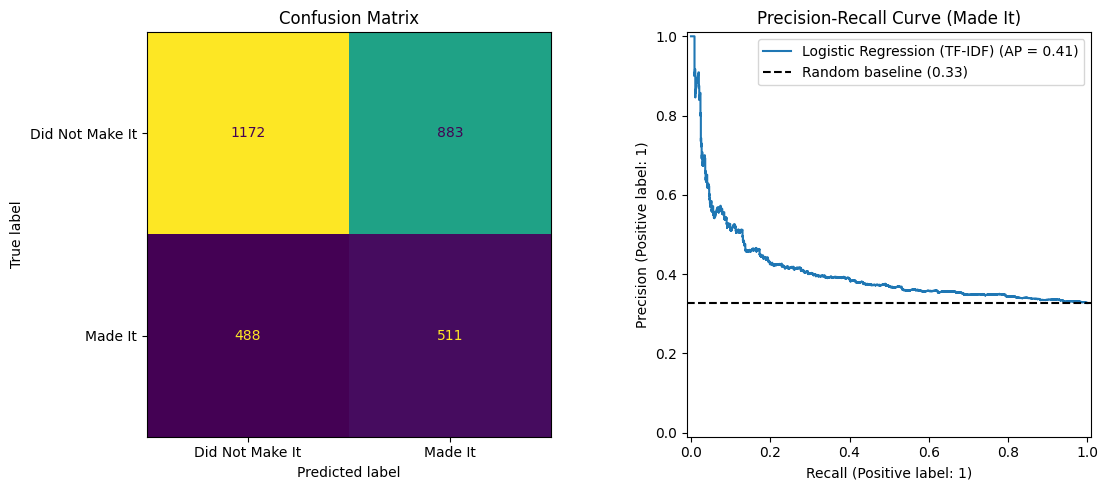

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    Labels, y_pred,
    display_labels=['Did Not Make It', 'Made It'],
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title('Confusion Matrix')

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(
    Labels, y_pred_proba,
    ax=axes[1],
    name='Logistic Regression (TF-IDF)'
)
axes[1].axhline(
    y=baseline, color='k', linestyle='--',
    label=f'Random baseline ({baseline:.2f})'
)
axes[1].set_title('Precision-Recall Curve (Made It)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Top Coefficients

Unlike Random Forest, Logistic Regression gives **signed coefficients** — positive coefficients push toward "made it", negative toward "did not make it". This gives us a direct, interpretable read on which scouting adjectives predict success vs bust.

We refit on the full dataset to extract coefficients from all available data.

/Users/oltarecica/Desktop/nfl-draft-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


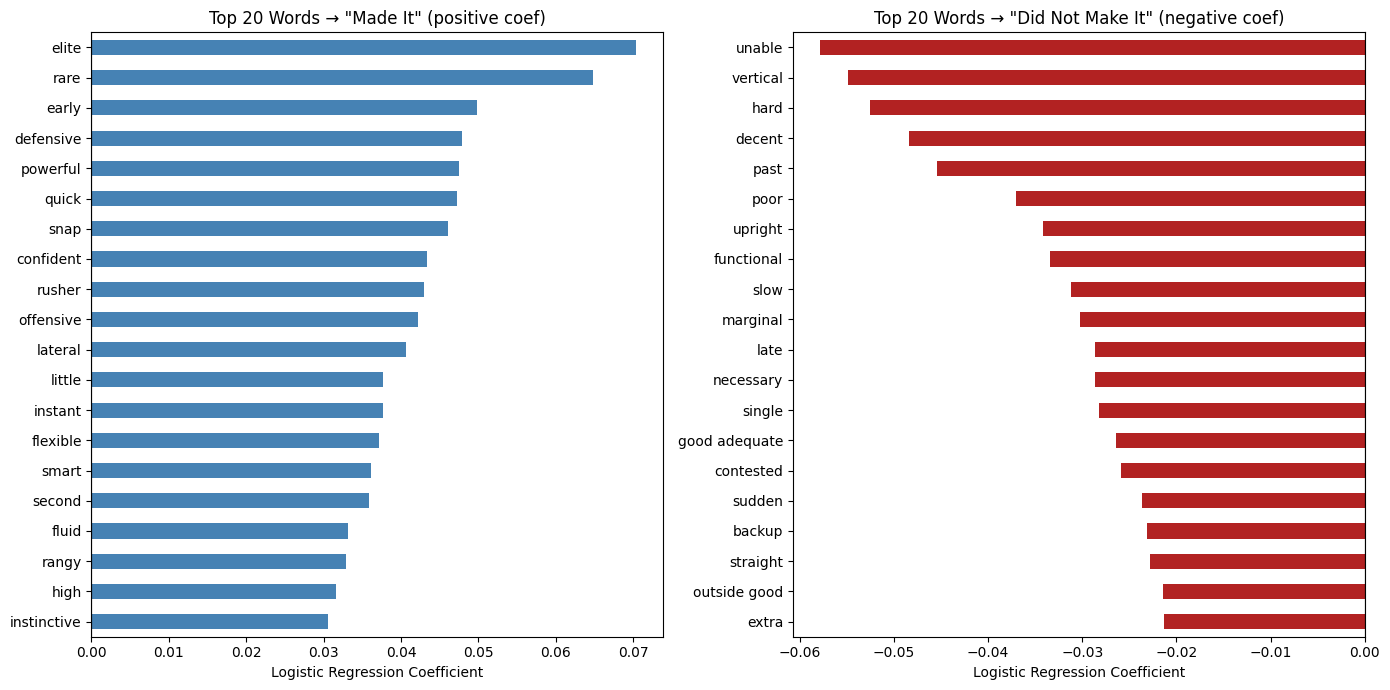

In [11]:
best_clf.fit(Texts, Labels)

feature_names = np.array(best_clf.named_steps['vect'].get_feature_names_out())
coefs = best_clf.named_steps['clf'].coef_[0]  # shape: (n_features,)

TOP_N = 20

# Top positive (predicts "made it")
top_pos_idx = np.argsort(coefs)[::-1][:TOP_N]
# Top negative (predicts "did not make it" / bust)
top_neg_idx = np.argsort(coefs)[:TOP_N]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Positive coefficients → "made it"
pos_series = pd.Series(coefs[top_pos_idx], index=feature_names[top_pos_idx]).sort_values()
pos_series.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].set_title(f'Top {TOP_N} Words → "Made It" (positive coef)')
axes[0].axvline(0, color='black', linewidth=0.8)

# Negative coefficients → "did not make it"
neg_series = pd.Series(coefs[top_neg_idx], index=feature_names[top_neg_idx]).sort_values(ascending=False)
neg_series.plot.barh(ax=axes[1], color='firebrick')
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].set_title(f'Top {TOP_N} Words → "Did Not Make It" (negative coef)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 10. Coefficient Table

In [12]:
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df['direction'] = coef_df['coefficient'].apply(lambda x: 'made_it' if x > 0 else 'bust')
coef_df = coef_df.sort_values('coefficient', ascending=False).reset_index(drop=True)

print("=== Top 20 'Made It' signals ===")
print(coef_df.head(20)[['feature', 'coefficient']].to_string(index=False))
print()
print("=== Top 20 'Bust' signals ===")
print(coef_df.tail(20)[['feature', 'coefficient']].iloc[::-1].to_string(index=False))

=== Top 20 'Made It' signals ===
    feature  coefficient
      elite     0.070335
       rare     0.064769
      early     0.049802
  defensive     0.047823
   powerful     0.047447
      quick     0.047235
       snap     0.046101
  confident     0.043332
     rusher     0.042960
  offensive     0.042162
    lateral     0.040640
     little     0.037717
    instant     0.037650
   flexible     0.037113
      smart     0.036130
     second     0.035935
      fluid     0.033165
      rangy     0.032939
       high     0.031547
instinctive     0.030600

=== Top 20 'Bust' signals ===
      feature  coefficient
       unable    -0.057828
     vertical    -0.054912
         hard    -0.052495
       decent    -0.048352
         past    -0.045397
         poor    -0.037064
      upright    -0.034175
   functional    -0.033431
         slow    -0.031195
     marginal    -0.030254
         late    -0.028694
    necessary    -0.028631
       single    -0.028227
good adequate    -0.026420
    co